# nb45: Compton-Y$^2$ ratio, fgas+2$\sigma$ vs fiducial, in $(M_{500c}, z)$ bins

**Question.** How much more does the weak-feedback FLAMINGO run (`fgas+2sigma`) contribute to the
tSZ signal ($\sum Y^2$) than the fiducial (`L1_m9`) run, as a function of halo mass and redshift?

**Quantity.** Per $(M_{500c}, z)$ bin, $S(M,z)=\sum_{i\in\mathrm{bin}} Y_i^2$ (the 1-halo / shot-noise
contribution to the tSZ power). Ratio $R=S_{\mathrm fgas+2\sigma}/S_{\rm fiducial}$.

**Radius (explicit).** Both apertures are stored, with AGN:
`Y_500c_Mpc2` (within $R_{500c}$) and `Y_5R500c_Mpc2` (within $5R_{500c}$, Planck-style total flux).
We report both.

> **DATA CAVEAT (important).** The `fgas+2sigma` catalogue has Compton-Y populated **only for
> snapshots 17-25**, i.e. $z\in[2.575,3.0]$ (515,399 of 26,088,053 rows finite; the rest are NaN).
> The SOAP-Y append for this run evidently stopped after snap 25. The fiducial run has complete Y.
> Therefore a *valid* ratio can only be formed in the overlap window $z\in[2.575,3.0]$, where at that
> redshift halos span only $\log_{10}(M_{500c}/M_\odot)\in[13.0,13.85]$ (no cluster-scale halos exist
> that early). The full $(M,z)$ map requested is **not possible** until the fgas+2$\sigma$ Y append is
> completed; see the completeness diagnostic below.

In [ ]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"text.usetex": False, "font.family": "serif", "font.size": 11,
                     "axes.labelsize": 12, "axes.titlesize": 11, "legend.fontsize": 9,
                     "figure.dpi": 120})

CAT_DIR = Path("/rds/rds-lxu/flamingo/L1_m9/catalogues")
FILES = {"fiducial":    CAT_DIR / "halo_catalogue_M500c_1e13_zlt3_L1_m9_yang26rot.csv",
         "fgas+2sigma": CAT_DIR / "halo_catalogue_M500c_1e13_zlt3_fgas+2sigma_yang26rot.csv"}
USECOLS = ["snap", "z", "M_500c_Msun", "Y_500c_Mpc2", "Y_5R500c_Mpc2"]
RADII = ["Y_500c_Mpc2", "Y_5R500c_Mpc2"]
FIG_DIR = Path("/scratch/scratch-lxu/flamingo_repo/figures/nb45_compton_y2_ratio_fgas2sigma_Mz")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def load_cat(path):
    t0 = time.time()
    df = pd.read_csv(path, comment="#", usecols=USECOLS,
                     dtype={c: np.float64 for c in USECOLS if c != "snap"})
    print(f"  {path.name}: {len(df):,} rows in {time.time()-t0:.1f}s")
    return df

dfs = {n: load_cat(p) for n, p in FILES.items()}

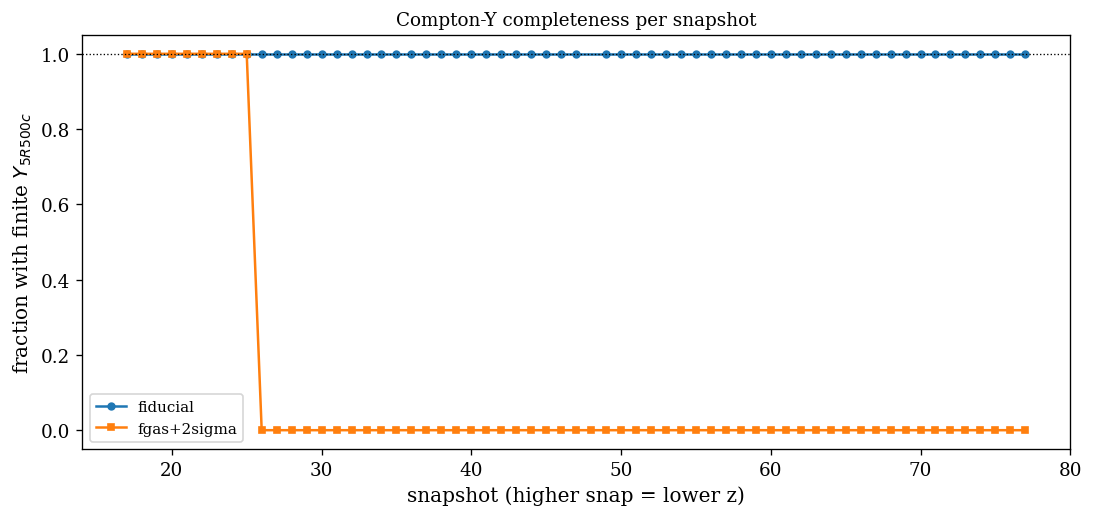

fiducial: finite Y = 24,414,876 / 24,414,876
fgas+2sigma: finite Y = 515,399 / 26,088,053


In [ ]:
# --- Completeness diagnostic: finite-Y fraction per snapshot, both runs ---
fig, ax = plt.subplots(figsize=(9, 4.2), constrained_layout=True)
for name, mk in zip(FILES, ["o", "s"]):
    df = dfs[name]
    g = df.groupby("snap").apply(
        lambda d: np.isfinite(d["Y_5R500c_Mpc2"]).mean(), include_groups=False)
    ax.plot(g.index, g.values, mk + "-", ms=4, label=name)
ax.set_xlabel("snapshot (higher snap = lower z)")
ax.set_ylabel("fraction with finite $Y_{5R500c}$")
ax.set_title("Compton-Y completeness per snapshot")
ax.axhline(1.0, color="k", ls=":", lw=0.8); ax.legend()
fig.savefig(FIG_DIR / "Y_completeness.png", dpi=200, bbox_inches="tight")
fig.savefig(FIG_DIR / "Y_completeness.pdf", bbox_inches="tight")
plt.show()

for name in FILES:
    y = dfs[name]["Y_5R500c_Mpc2"]
    print(f"{name}: finite Y = {int(np.isfinite(y).sum()):,} / {len(y):,}")

In [ ]:
# --- Restrict to the overlap window where BOTH runs have Y ---
ZLO, ZHI = 2.575, 3.0
M_EDGES = np.logspace(13.0, 13.85, 8)          # 7 mass bins (only range populated at z~2.6-3)
Z_EDGES = np.array([2.575, 2.72, 2.86, 3.0])   # 3 z sub-bins, both runs fully cover these
M_CEN = np.sqrt(M_EDGES[:-1] * M_EDGES[1:])
Z_CEN = 0.5 * (Z_EDGES[:-1] + Z_EDGES[1:])

def sumsq_counts(df, ycol):
    m, z, y = df["M_500c_Msun"].to_numpy(), df["z"].to_numpy(), df[ycol].to_numpy()
    ok = np.isfinite(m) & np.isfinite(z) & np.isfinite(y) & (z >= ZLO) & (z <= ZHI)
    m, z, y = m[ok], z[ok], y[ok]
    s, _, _ = np.histogram2d(m, z, bins=[M_EDGES, Z_EDGES], weights=y**2)
    c, _, _ = np.histogram2d(m, z, bins=[M_EDGES, Z_EDGES])
    return s, c

MIN_COUNT = 20
ratios = {}
for r in RADII:
    s_fid, c_fid = sumsq_counts(dfs["fiducial"], r)
    s_alt, c_alt = sumsq_counts(dfs["fgas+2sigma"], r)
    ok = (c_fid >= MIN_COUNT) & (c_alt >= MIN_COUNT) & (s_fid > 0)
    R = np.full_like(s_fid, np.nan); R[ok] = s_alt[ok] / s_fid[ok]
    ratios[r] = R
    print(f"{r}: valid bins {int(ok.sum())}/{R.size}, "
          f"ratio median {np.nanmedian(R):.3f} range [{np.nanmin(R):.3f},{np.nanmax(R):.3f}]")

Y_500c_Mpc2: valid bins 20/21, ratio median 1.057 range [0.907,1.223]


Y_5R500c_Mpc2: valid bins 20/21, ratio median 0.954 range [0.865,1.085]


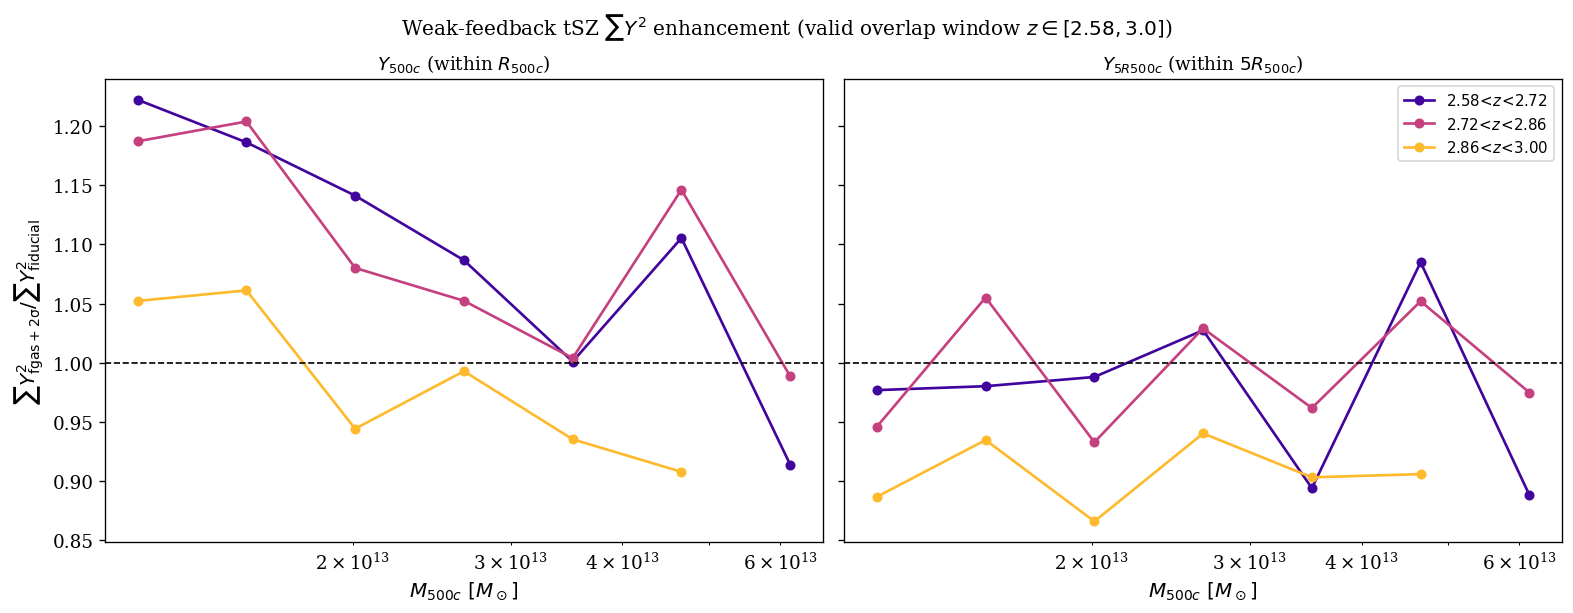

In [ ]:
# --- Figure: sum(Y^2) ratio vs mass, one line per z sub-bin, one panel per aperture ---
labels = {"Y_500c_Mpc2": r"$Y_{500c}$ (within $R_{500c}$)",
          "Y_5R500c_Mpc2": r"$Y_{5R500c}$ (within $5R_{500c}$)"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0), sharey=True, constrained_layout=True)
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(Z_CEN)))
for ax, r in zip(axes, RADII):
    for j in range(len(Z_CEN)):
        ax.plot(M_CEN, ratios[r][:, j], "o-", ms=5, color=colors[j], lw=1.6,
                label=rf"${Z_EDGES[j]:.2f}\!<\!z\!<\!{Z_EDGES[j+1]:.2f}$")
    ax.axhline(1.0, color="k", ls="--", lw=1.0)
    ax.set_xscale("log"); ax.set_xlabel(r"$M_{500c}\ [M_\odot]$"); ax.set_title(labels[r])
axes[0].set_ylabel(r"$\sum Y^2_{\mathrm{fgas+2\sigma}} / \sum Y^2_{\mathrm{fiducial}}$")
axes[1].legend(loc="best")
fig.suptitle(r"Weak-feedback tSZ $\sum Y^2$ enhancement (valid overlap window $z\in[2.58,3.0]$)",
             fontsize=12)
fig.savefig(FIG_DIR / "sumY2_ratio_vsM_overlap.png", dpi=200, bbox_inches="tight")
fig.savefig(FIG_DIR / "sumY2_ratio_vsM_overlap.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# Numeric table (Y_5R500c)
r = "Y_5R500c_Mpc2"
print("Ratio sum(Y^2) fgas+2sigma / fiducial  [5 R500c], z in [2.58,3.0]")
print("logM_cen |" + "".join(f"  z={zc:.2f}" for zc in Z_CEN))
for i in range(len(M_CEN)):
    row = f"  {np.log10(M_CEN[i]):6.2f} |"
    for j in range(len(Z_CEN)):
        v = ratios[r][i, j]; row += f"  {v:6.2f}" if np.isfinite(v) else "     ---"
    print(row)

Ratio sum(Y^2) fgas+2sigma / fiducial  [5 R500c], z in [2.58,3.0]
logM_cen |  z=2.65  z=2.79  z=2.93
   13.06 |    0.98    0.95    0.89
   13.18 |    0.98    1.06    0.93
   13.30 |    0.99    0.93    0.87
   13.43 |    1.03    1.03    0.94
   13.55 |    0.89    0.96    0.90
   13.67 |    1.08    1.05    0.91
   13.79 |    0.89    0.97     ---
